# Communities Detection

## Libs install

In [50]:
import os
import networkx as nx
import statistics
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from pathlib import Path
from sklearn.cluster import SpectralClustering
from cdlib import algorithms

In [2]:
code_theme = 70

G = nx.read_gexf(f'../graphs/theme_normalized/normalized_{code_theme}.gexf')

isolated = list(nx.isolates(G))
G.remove_nodes_from(isolated)

positive_edges = [(u, v, d) for u, v, d in G.edges(data=True) if d['weight'] > 0]
G_positive = nx.Graph()
G_positive.add_nodes_from(G.nodes(data=True))
G_positive.add_edges_from(positive_edges)

## Leidein

In [3]:
coms = algorithms.leiden(G_positive)

In [6]:
def leiden_to_dict(communities):
    return {node: i 
            for i, community in enumerate(communities.communities) 
            for node in community}

In [6]:
coms_leiden = leiden_to_dict(coms)

In [ ]:
coms_leiden

## Label Propagation

In [7]:
import random

def signed_label_propagation(G, max_iter=100):
    # Cada nó começa com sua própria comunidade
    # Usamos o próprio nó como rótulo inicial
    labels = {node: node for node in G.nodes()}
    
    for _ in range(max_iter):
        # Iteramos sobre os nós em ordem aleatória
        # para evitar viés de ordem de atualização
        nodes = list(G.nodes())
        random.shuffle(nodes)
        
        changed = False
        for node in nodes:
            # Acumulamos o "peso" de cada comunidade vizinha
            # levando em conta o sinal da aresta
            community_weights = {}
            for neighbor in G.neighbors(node):
                weight = G[node][neighbor].get('weight', 0)
                neighbor_label = labels[neighbor]
                
                if neighbor_label not in community_weights:
                    community_weights[neighbor_label] = 0
                # Peso positivo reforça a comunidade do vizinho
                # Peso negativo penaliza a comunidade do vizinho
                community_weights[neighbor_label] += weight
            
            if not community_weights:
                continue
            
            # Adota a comunidade com maior peso acumulado
            best_label = max(community_weights, key=community_weights.get)
            
            if best_label != labels[node]:
                labels[node] = best_label
                changed = True
        
        # Se nenhum nó mudou de comunidade, convergiu
        if not changed:
            break
    
    # Converte para o formato padrão do NetworkX:
    # dicionário {nó: id_comunidade}
    # Remapeamos os rótulos para inteiros sequenciais
    unique_labels = {label: idx for idx, label in enumerate(set(labels.values()))}
    return {node: unique_labels[label] for node, label in labels.items()}

In [5]:
coms_label = signed_label_propagation(G)

In [ ]:
coms_label

## Spectral Clustering

In [8]:
nodes = list(G.nodes())
G_matrix = nx.to_numpy_array(G_positive, nodelist=nodes)

In [10]:
clustering = SpectralClustering(n_clusters=len(coms.communities)).fit(G_matrix)

In [8]:
def spectral_to_dict(labels, nodes):
    return {node: int(label) 
            for node, label in zip(nodes, labels)}

In [13]:
coms_spectral = spectral_to_dict(clustering.labels_, nodes)

In [ ]:
coms_spectral

## Iterate Over Each Theme

In [3]:
import duckdb
import json

duckdb_path = os.getenv("DUCKDB_PATH")
assert duckdb_path is not None, "Variable 'DUCKDB_PATH' must be defined"

con = duckdb.connect(duckdb_path)

In [4]:
themes = con.execute("""
    SELECT
        pt.codTema as code,
        pt.tema as theme,
        COALESCE(SUM(pp.polls_count), 0)::INT as polls_count
    FROM proposicoesTemas pt
    LEFT JOIN (
        SELECT
            vo.proposicao_id,
            COUNT(vo.idVotacao) as polls_count
        FROM votacoesObjetos vo
        JOIN votacoesVotos vv ON vv.idVotacao = vo.idVotacao
        GROUP BY vo.proposicao_id
    ) pp ON pp.proposicao_id = pt.proposicao_id
    GROUP BY 1, 2
    ORDER BY 3 DESC
""").df()

voted_themes = themes[themes['polls_count'] > 0]

voted_themes

,code,theme,polls_count
0,34,Administração Pública,16661
1,70,Finanças Públicas e Orçamento,11161
2,40,Economia,6431
3,51,Estrutura Fundiária,3946
4,54,"Energia, Recursos Hídricos e Minerais",3126
5,44,Direitos Humanos e Minorias,3126
6,67,Direito e Defesa do Consumidor,3126
7,42,Direito Civil e Processual Civil,2901
8,66,"Indústria, Comércio e Serviços",2370
9,56,Saúde,2011


In [124]:
labels_dict = dict()

for theme in voted_themes.itertuples():
    code_theme = theme.code

    G = nx.read_gexf(f'../graphs/theme_normalized/normalized_{code_theme}.gexf')

    isolated = list(nx.isolates(G))
    G.remove_nodes_from(isolated)

    positive_edges = [(u, v, d) for u, v, d in G.edges(data=True) if d['weight'] > 0]
    G_positive = nx.Graph()
    G_positive.add_nodes_from(G.nodes(data=True))
    G_positive.add_edges_from(positive_edges)
    
    coms_label = signed_label_propagation(G_positive)

    labels_dict[code_theme] = coms_label

with open("../graphs/communities/labels.json", "w") as file:
    json.dump(labels_dict, file, indent=4)

In [10]:
leiden_dict = dict()

for theme in voted_themes.itertuples():
    code_theme = theme.code

    G = nx.read_gexf(f'../graphs/theme_normalized/normalized_{code_theme}.gexf')

    isolated = list(nx.isolates(G))
    G.remove_nodes_from(isolated)

    positive_edges = [(u, v, d) for u, v, d in G.edges(data=True) if d['weight'] > 0]
    G_positive = nx.Graph()
    G_positive.add_nodes_from(G.nodes(data=True))
    G_positive.add_edges_from(positive_edges)

    coms = algorithms.leiden(G_positive)
    coms_leiden = leiden_to_dict(coms)
    
    leiden_dict[code_theme] = coms_leiden

with open("../graphs/communities/leiden.json", "w") as file:
    json.dump(leiden_dict, file, indent=4)

In [140]:
spectral_dict = dict()

for theme in voted_themes.itertuples():
    code_theme = theme.code

    G = nx.read_gexf(f'../graphs/theme_normalized/normalized_{code_theme}.gexf')

    isolated = list(nx.isolates(G))
    G.remove_nodes_from(isolated)

    positive_edges = [(u, v, d) for u, v, d in G.edges(data=True) if d['weight'] > 0]
    G_positive = nx.Graph()
    G_positive.add_nodes_from(G.nodes(data=True))
    G_positive.add_edges_from(positive_edges)

    nodes = list(G_positive.nodes())
    G_matrix = nx.to_numpy_array(G_positive, nodelist=nodes)

    clustering = SpectralClustering(n_clusters=len(set(leiden_dict[code_theme].values())), affinity='precomputed').fit(G_matrix)

    coms_spectral = spectral_to_dict(clustering.labels_, nodes)
    
    spectral_dict[code_theme] = coms_spectral

with open("../graphs/communities/spectral.json", "w") as file:
    json.dump(spectral_dict, file, indent=4)

## Communities modularity

In [132]:
communities_dict = dict()

with open("../graphs/communities/labels.json", "r") as file:
    communities_dict['label_propagation'] = json.load(file)

with open("../graphs/communities/leiden.json", "r") as file:
    communities_dict['leiden'] = json.load(file)

with open("../graphs/communities/spectral.json", "r") as file:
    communities_dict['spectral'] = json.load(file)

In [133]:
def communities_dict_to_list(comms_dict):
    communities_list = [set()]
    for key in comms_dict.keys():
        value = comms_dict[key]
        if (value + 1 > len(communities_list)):
            communities_list.extend(set() for _ in range(value + 1 - len(communities_list)))
    
        communities_list[value].add(key)
    
    return communities_list

In [141]:
modularities = {
    'label_propagation': {},
    'leiden': {},
    'spectral': {}
}

In [142]:
for theme in voted_themes.itertuples():
    code_theme = theme.code
    name_theme = theme.theme

    G = nx.read_gexf(f'../graphs/theme_normalized/normalized_{code_theme}.gexf')
    isolated = list(nx.isolates(G))
    G.remove_nodes_from(isolated)

    positive_edges = [(u, v, d) for u, v, d in G.edges(data=True) if d['weight'] > 0]
    G_positive = nx.Graph()
    G_positive.add_nodes_from(G.nodes(data=True))
    G_positive.add_edges_from(positive_edges)

    for method in communities_dict.keys():
        theme_dict = communities_dict[method][f'{code_theme}']
    
        comm_list = communities_dict_to_list(theme_dict)

        modularity = nx.community.modularity(G_positive, comm_list)

        modularities[method][name_theme] = modularity

In [143]:
df = pd.DataFrame(modularities)

In [144]:
df

,label_propagation,leiden,spectral
Administração Pública,-6.084022e-14,0.172638,-2.395451e-06
Finanças Públicas e Orçamento,-1.887379e-15,0.125214,-2.212977e-06
Economia,2.819966e-14,0.154843,-3.509694e-06
Estrutura Fundiária,1.801134e-01,0.207834,-1.816756e-06
"Energia, Recursos Hídricos e Minerais",1.118328e-01,0.131741,-1.206223e-04
Direitos Humanos e Minorias,1.118328e-01,0.131741,-1.206223e-04
Direito e Defesa do Consumidor,1.118328e-01,0.131741,-1.206223e-04
Direito Civil e Processual Civil,2.138249e-01,0.214057,5.876409e-05
"Indústria, Comércio e Serviços",1.280728e-01,0.207256,-3.919629e-06
Saúde,4.688322e-02,0.136655,-1.303632e-05


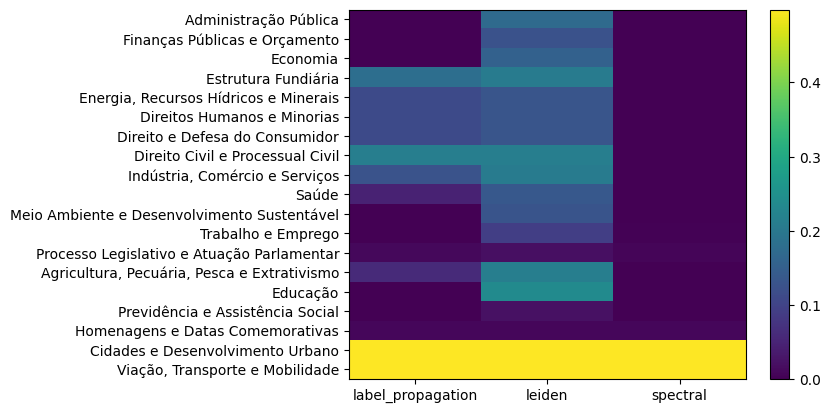

In [145]:
plt.imshow(df.values, aspect='auto')
plt.xticks(range(len(df.columns)), df.columns)
plt.yticks(range(len(df.index)), df.index)
plt.colorbar()

In [118]:
common_polls = con.execute("""
SELECT 
    pt.codTema,
    pt.tema,
    array_agg(DISTINCT vo.idVotacao ORDER BY vo.idVotacao) as votacoes
FROM votacoesObjetos vo
JOIN proposicoesTemas pt ON vo.proposicao_id = pt.proposicao_id
GROUP BY pt.codTema, pt.tema
ORDER BY votacoes
""").df()

In [122]:
common_polls["votacoes_tuple"] = common_polls["votacoes"].apply(tuple)

identical_themes = common_polls.groupby("votacoes_tuple").agg({
    "codTema": list,
    "tema": list
}).reset_index()

identical_grouped = identical_themes[identical_themes["tema"].apply(len) > 1]

In [123]:
identical_themes

,votacoes_tuple,codTema,tema
0,"(2336439-37, 2336439-38, 2336439-42, 2336439-4...",[70],[Finanças Públicas e Orçamento]
1,"(2336439-37, 2336439-38, 2336439-42, 2336439-4...",[40],[Economia]
2,"(2336439-37, 2336439-38, 2336439-42, 2336439-4...",[66],"[Indústria, Comércio e Serviços]"
3,"(2336440-41, 2336440-42, 2336440-44, 2336440-4...",[34],[Administração Pública]
4,"(2336440-41, 2336440-42, 2336440-44, 2336440-4...",[44],[Direitos Humanos e Minorias]
5,"(2336440-41, 2336440-42, 2336440-44, 2336440-4...",[57],[Defesa e Segurança]
6,"(2340309-29, 2340309-31, 2340309-33, 2347231-1...",[56],[Saúde]
7,"(2340309-29, 2340309-31, 2340309-33, 2349576-1...",[58],[Trabalho e Emprego]
8,"(2344542-30, 2344542-32, 2344542-34, 2361827-1...",[55],[Relações Internacionais e Comércio Exterior]
9,"(2345368-46, 2345368-48, 2345368-50, 2345368-5...",[48],[Meio Ambiente e Desenvolvimento Sustentável]


## NVI Analysis

In [ ]:
from sklearn.metrics import normalized_mutual_info_score